# 02 — CATE estimators & honest evaluation

**Stage 2.** Four learners (T-, X-, DR-learner, causal forest; configs fixed
by HYPOTHESES.md amendment A1) produce out-of-fold CATE predictions on the
1M-row dev subsample via 5-fold cross-fitting on the hashed folds. This
notebook is the evaluation record: Qini/AUUC comparison with bootstrap CIs,
GATES decile calibration, the pre-registered **H1** heterogeneity test, and
the exploratory CLAN profile.

Runs on committed artifacts (`results/stage2/`, produced by
`scripts/02_fit_cate.py`) + the dev parquet; every displayed number is
asserted. The synthetic-recovery hard gate lives in
`tests/test_gate_stage2.py` — every learner shown here recovered a known
CATE within tolerance before being allowed near real data.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from how_wrong import data
from how_wrong.evaluate import blp_test, qini_coefficient, qini_curve

STAGE2 = data.PROJECT_ROOT / "results" / "stage2"
metrics = json.loads((STAGE2 / "metrics.json").read_text())
h1 = json.loads((STAGE2 / "h1_blp.json").read_text())
oof = pd.read_parquet(STAGE2 / "oof_cate.parquet")
gates = pd.read_csv(STAGE2 / "gates_deciles.csv")
dev = data.load_criteo_dev()
assert (oof["row_id"].to_numpy() == dev["row_id"].to_numpy()).all()

LEARNERS = ["t_learner", "x_learner", "dr_learner", "causal_forest"]
# fixed categorical slot order — never re-assigned when filtering
HUES = {"t_learner": "#2a78d6", "x_learner": "#008300",
        "dr_learner": "#e87ba4", "causal_forest": "#eda100"}
INK, MUTED = "#1a1a19", "#6b6a63"
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e5e4dd", "grid.linewidth": 0.6,
    "axes.axisbelow": True, "text.color": INK, "axes.labelcolor": MUTED,
    "xtick.color": MUTED, "ytick.color": MUTED,
})
f"OOF predictions: {len(oof):,} rows x {len(oof.columns)-1} learner-outcome columns"


'OOF predictions: 1,000,000 rows x 8 learner-outcome columns'

## 1. Learner comparison — Qini with bootstrap CIs

Qini coefficient = average incremental successes per person over random
targeting (own definition, see `evaluate.py`); `auuc_normalized` is
causalml's normalized AUUC, shown because a comparable published campus
project reports **AUUC 0.64 with an S-Learner** on this dataset (context,
not a target — definitions differ across the literature).

In [2]:
rows = []
for outcome in ["visit", "conversion"]:
    for name in LEARNERS:
        m = metrics[outcome][name]
        rows.append({
            "outcome": outcome, "learner": name,
            "qini": m["qini"]["point"], "qini_ci_lo": m["qini"]["ci_lo"],
            "qini_ci_hi": m["qini"]["ci_hi"], "auuc_norm": m["auuc_normalized"],
        })
table = pd.DataFrame(rows).set_index(["outcome", "learner"])

# spot-check: the stored primary metric must be recomputable from the OOF file
q = qini_coefficient(dev["visit"], dev["treatment"], oof["visit_dr_learner"])
assert q == metrics["visit"]["dr_learner"]["qini"]["point"]

table.style.format({"qini": "{:.6f}", "qini_ci_lo": "{:.6f}",
                    "qini_ci_hi": "{:.6f}", "auuc_norm": "{:.4f}"})


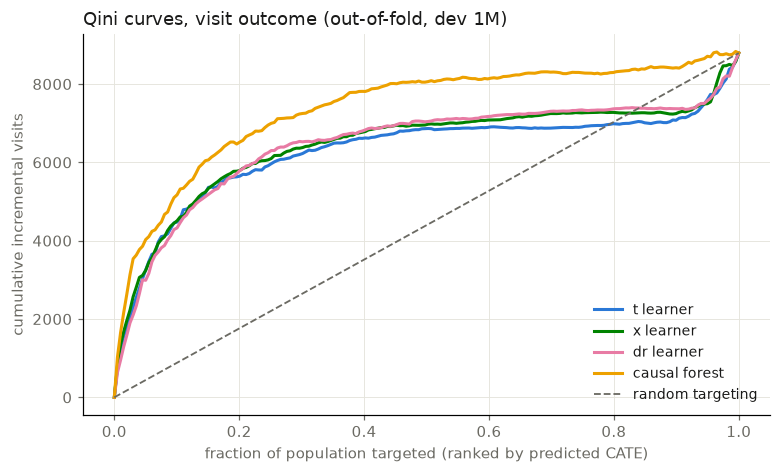

In [3]:
fig, ax = plt.subplots(figsize=(7.2, 4.4))
for name in LEARNERS:
    c = qini_curve(dev["visit"], dev["treatment"], oof[f"visit_{name}"])
    ax.plot(c["frac_targeted"], c["qini"], color=HUES[name], lw=2,
            label=name.replace("_", " "))
c0 = qini_curve(dev["visit"], dev["treatment"], oof["visit_dr_learner"])
ax.plot(c0["frac_targeted"], c0["random"], color=MUTED, lw=1.2, ls="--",
        label="random targeting")
ax.set_xlabel("fraction of population targeted (ranked by predicted CATE)")
ax.set_ylabel("cumulative incremental visits")
ax.set_title("Qini curves, visit outcome (out-of-fold, dev 1M)",
             loc="left", color=INK)
ax.legend(frameon=False, loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()


> **A trap this dataset sets for you:** the raw Criteo file is
> *treatment-block-ordered* — entire 50k-row spans are single-arm. Tree
> learners also produce heavily tied CATE predictions on the rare
> `conversion` outcome (up to ~80% tied, ~50% exactly 0.0 for the forest).
> Break ranking ties by row position — as a stable sort silently does — and
> rank becomes correlated with *treatment* inside tied blocks, corrupting
> every rank-based metric. All metrics here use seeded-random tie-breaking
> (`evaluate.py`), and the regression test
> `test_rank_metrics_immune_to_treatment_ordered_ties` keeps it that way.

## 2. GATES decile calibration — do predicted effects materialize?

Rank users into deciles by out-of-fold predicted CATE; within each decile the
realized effect is a clean diff-in-means (treatment is randomized within any
score group). A calibrated learner puts its deciles on the 45° line; a
useful-but-miscalibrated one at least orders them.

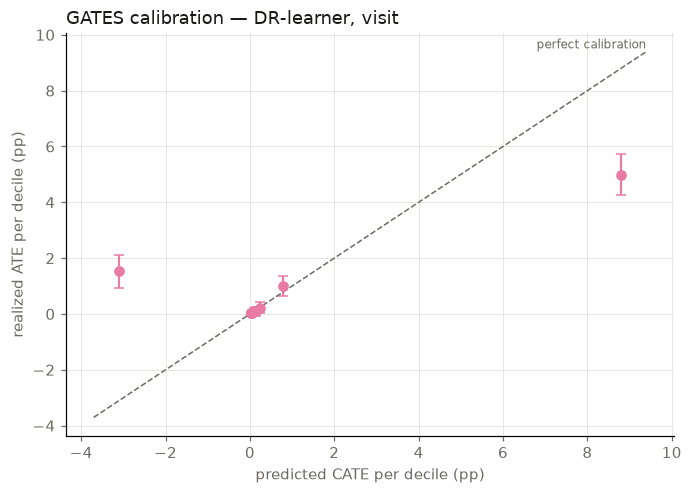

decile 10 realized: +4.99pp [+4.26, +5.72]
decile 1  realized: +1.53pp [+0.93, +2.12]


In [4]:
g = gates[(gates.outcome == "visit") & (gates.learner == "dr_learner")]
fig, ax = plt.subplots(figsize=(6.4, 4.6))
ax.errorbar(g["predicted_cate"] * 100, g["realized_ate"] * 100,
            yerr=1.96 * g["se"] * 100, fmt="o", color=HUES["dr_learner"],
            ms=6, lw=1.4, capsize=3)
lims = ax.get_xlim()
ax.plot(lims, lims, color=MUTED, lw=1, ls="--")
ax.text(lims[1], lims[1], "perfect calibration", color=MUTED, fontsize=8,
        ha="right", va="bottom")
ax.set_xlabel("predicted CATE per decile (pp)")
ax.set_ylabel("realized ATE per decile (pp)")
ax.set_title("GATES calibration — DR-learner, visit", loc="left", color=INK)
plt.tight_layout()
plt.show()

top, bot = g[g.group == 10].iloc[0], g[g.group == 1].iloc[0]
print(f"decile 10 realized: {top.realized_ate*100:+.2f}pp "
      f"[{top.ci_lo*100:+.2f}, {top.ci_hi*100:+.2f}]")
print(f"decile 1  realized: {bot.realized_ate*100:+.2f}pp "
      f"[{bot.ci_lo*100:+.2f}, {bot.ci_hi*100:+.2f}]")


## 3. H1 — does treatment-effect heterogeneity exist?

Pre-registered (A1): BLP of `visit` on the DR-learner's out-of-fold proxy,
p = 0.85 known, HC3 SEs. β₂ is the heterogeneity loading (1 = perfectly
calibrated proxy, 0 = no heterogeneity signal). Support for H1 requires
β₂ > 0 with p < 0.05 after Holm across H1–H3; the strictest possible Holm
threshold with three primaries is α/3, applied provisionally here until
H2/H3 land.

In [5]:
blp = h1["primary"]["blp"]
# the committed test must be recomputable from committed predictions
re = blp_test(dev["visit"], dev["treatment"], oof["visit_dr_learner"], 0.85)
assert re["beta2_het"] == blp["beta2_het"]
assert re["beta2_p_value"] == blp["beta2_p_value"]

print(f"beta2 (heterogeneity loading): {blp['beta2_het']:.4f} "
      f"(se {blp['beta2_se']:.4f})")
print(f"raw p-value: {blp['beta2_p_value']:.3e}")
print(f"raw verdict (p<0.05, beta2>0): {h1['verdict_h1_raw']}")
holm_strict = blp["beta2_p_value"] < 0.05 / 3
print(f"survives strictest Holm threshold (alpha/3): {holm_strict}")

expl = pd.DataFrame({
    (o, n): {"beta2": h1["exploratory"][o][n]["beta2_het"],
             "p": h1["exploratory"][o][n]["beta2_p_value"]}
    for o in ["visit", "conversion"] for n in LEARNERS
}).T
expl.style.format({"beta2": "{:.4f}", "p": "{:.2e}"})


beta2 (heterogeneity loading): 0.3837 (se 0.0391)
raw p-value: 9.857e-23
raw verdict (p<0.05, beta2>0): True
survives strictest Holm threshold (alpha/3): True


## 4. CLAN — who are the persuadables? (exploratory, descriptive)

Covariate means in the top vs bottom 20% by predicted CATE (DR-learner,
visit), in SD units. Features are anonymized (f0–f11), so this profiles
*which* features separate responders, not who they are.

In [6]:
clan = pd.read_csv(STAGE2 / "clan_dr_visit.csv", index_col=0)
clan.style.format("{:.4f}").background_gradient(
    subset=["diff_in_sd"], cmap="RdBu_r", vmin=-1, vmax=1)


,mean_top,mean_bottom,diff_in_sd
f3,2.9765,4.3578,-1.0352
f8,3.8730,3.9273,-0.9594
f6,-7.1718,-3.3993,-0.8243
f0,16.8749,21.2932,-0.8217
f2,8.5500,8.3614,0.6303
f9,21.6249,17.5101,0.5865
f5,3.8355,4.0005,-0.3821
f7,5.6286,5.2059,0.3505
f1,10.0978,10.0710,0.2570
f10,5.3982,5.3638,0.2044


## Verdict

- Every learner passed the synthetic-recovery hard gate before touching
  real data (`pytest -m gate_stage2`).
- The comparison table + Qini curves above are the honest (out-of-fold,
  CI-carrying) learner ranking on the dev subsample.
- H1 verdict recorded above from the pre-registered test; final Holm
  adjudication happens once H2 and H3 report.

In [7]:
assert h1["primary"]["outcome"] == "visit"
assert h1["primary"]["proxy"] == "dr_learner"
print("notebook 02 assertions: ALL GREEN")


notebook 02 assertions: ALL GREEN
